<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Feature Detection em Reconstrução 3D

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

## Escopo e reprodutibilidade

Este notebook usa `cv2.SIFT_create()` para extrair keypoints e descritores SIFT. As células sobre espaço de escalas e Diferença de Gaussianas (DoG) são **inspeções didáticas** dos princípios do algoritmo; não constituem uma reimplementação completa do SIFT de Lowe.

A implementação completa inclui localização subpixel, interpolação em histogramas e regras próprias para múltiplas orientações. Os resultados numéricos podem variar com a versão do OpenCV e a plataforma.

Referências: [Lowe (2004)](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf) e [documentação do COLMAP](https://colmap.github.io/cli.html).

In [1]:
from pathlib import Path
import sys
from urllib.request import urlretrieve

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy
from PIL import Image
from scipy.ndimage import gaussian_filter

plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11})

print(f"Python: {sys.version.split()[0]}")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")

Python: 3.12.3
OpenCV: 4.11.0
NumPy: 1.26.4
SciPy: 1.17.1


## Carregar uma imagem do South Building

A imagem integra o conjunto [South Building](https://colmap.github.io/datasets.html), disponibilizado pelo projeto COLMAP e creditado a Christopher Zach. O recorte reduz o custo computacional e preserva textura arquitetônica para a análise.

Resolução original: 3072 × 2304
Resolução do recorte: 800 × 700


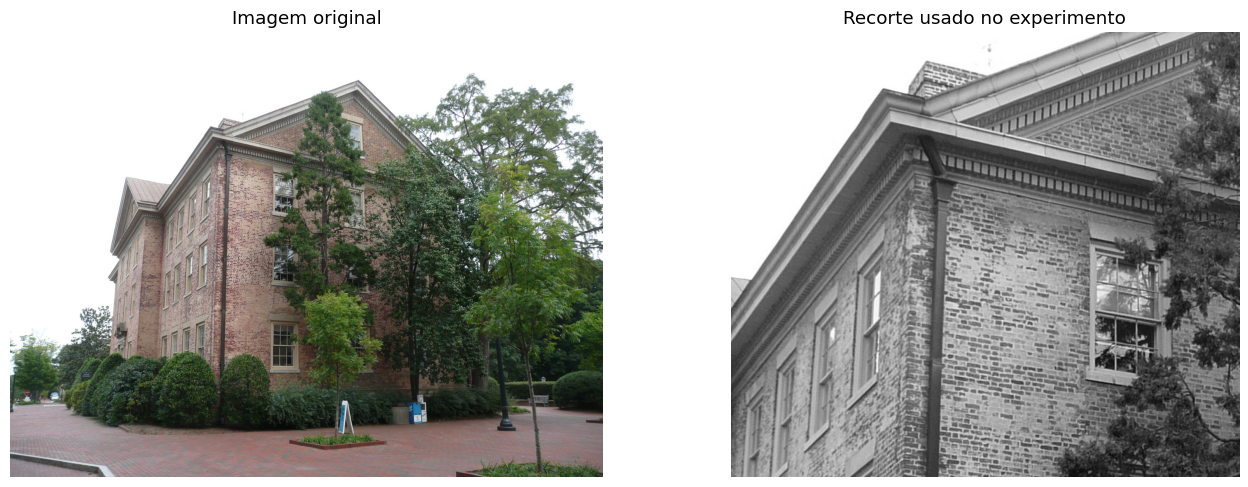

In [2]:
url_imagem = (
    "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/"
    "feature-detection-reconstrucao-3d/south_building_sample.jpg"
)
caminho_imagem = Path("south_building_sample.jpg")

if not caminho_imagem.exists():
    urlretrieve(url_imagem, caminho_imagem)

imagem_completa = Image.open(caminho_imagem).convert("RGB")
imagem_recorte = imagem_completa.crop((800, 400, 1600, 1100))
imagem_rgb = np.asarray(imagem_recorte)
imagem_cinza = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

print(f"Resolução original: {imagem_completa.width} × {imagem_completa.height}")
print(f"Resolução do recorte: {imagem_cinza.shape[1]} × {imagem_cinza.shape[0]}")

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].imshow(imagem_completa)
eixos[0].set_title("Imagem original")
eixos[1].imshow(imagem_cinza, cmap="gray")
eixos[1].set_title("Recorte usado no experimento")
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()

## Espaço de escalas e Diferença de Gaussianas

SIFT procura estruturas em escalas distintas. Com três níveis de escala por oitava, $k = 2^{1/3}$. A DoG aproxima o Laplaciano da Gaussiana normalizado pela escala e evidencia mudanças locais de intensidade.

Sigmas da primeira oitava: [1.6, 2.016, 2.54, 3.2, 4.032, 5.08]


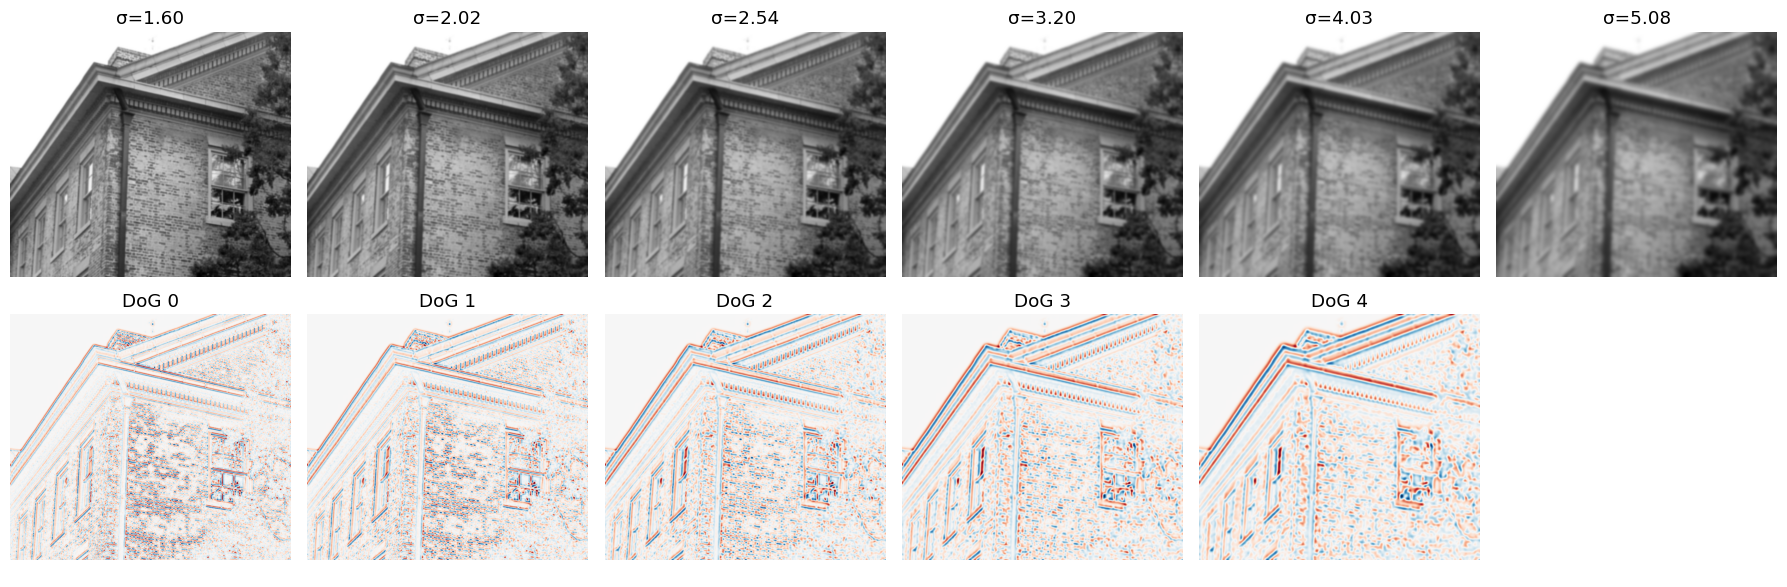

In [3]:
sigma_base = 1.6
niveis_por_oitava = 3
k = 2 ** (1 / niveis_por_oitava)
sigmas = [sigma_base * (k ** indice) for indice in range(niveis_por_oitava + 3)]
espaco_escalas = [
    gaussian_filter(imagem_cinza.astype(np.float64) / 255, sigma=sigma)
    for sigma in sigmas
]
dog = [espaco_escalas[indice + 1] - espaco_escalas[indice] for indice in range(len(espaco_escalas) - 1)]

print("Sigmas da primeira oitava:", [round(sigma, 3) for sigma in sigmas])
fig, eixos = plt.subplots(2, 6, figsize=(18, 6))
for indice, (imagem, sigma) in enumerate(zip(espaco_escalas, sigmas)):
    eixos[0, indice].imshow(imagem, cmap="gray")
    eixos[0, indice].set_title(f"σ={sigma:.2f}")
    eixos[0, indice].axis("off")
for indice, imagem in enumerate(dog):
    eixos[1, indice].imshow(imagem, cmap="RdBu", vmin=-0.05, vmax=0.05)
    eixos[1, indice].set_title(f"DoG {indice}")
    eixos[1, indice].axis("off")
eixos[1, -1].axis("off")
plt.tight_layout()

## Extrair keypoints e descritores com SIFT

Cada keypoint reúne posição, escala e orientação. Cada descritor SIFT tem 128 componentes e resume a distribuição local das orientações de gradiente.

Keypoints detectados: 10,982
Formato dos descritores: (10982, 128)
Tipo numérico: float32


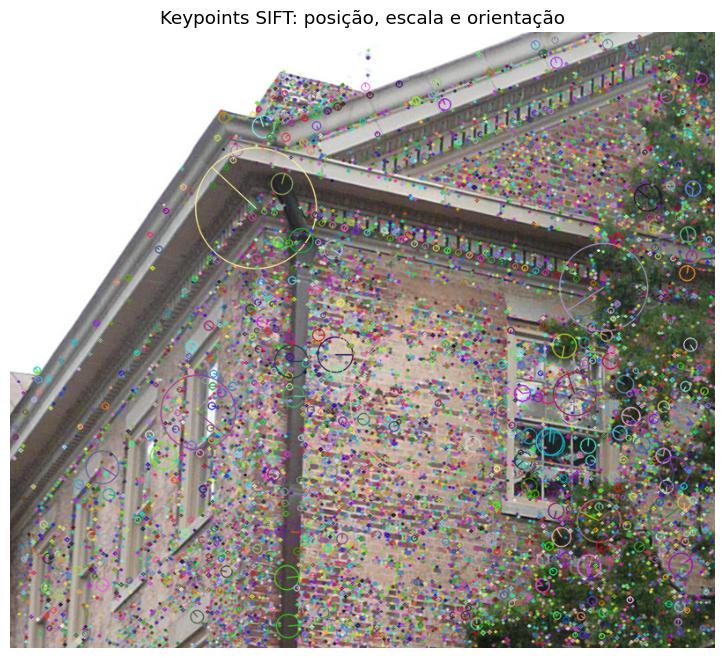

In [4]:
sift = cv2.SIFT_create()
keypoints, descritores = sift.detectAndCompute(imagem_cinza, None)

print(f"Keypoints detectados: {len(keypoints):,}")
print(f"Formato dos descritores: {descritores.shape}")
print(f"Tipo numérico: {descritores.dtype}")

imagem_keypoints = cv2.drawKeypoints(
    imagem_rgb, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
plt.figure(figsize=(12, 8))
plt.imshow(imagem_keypoints)
plt.title("Keypoints SIFT: posição, escala e orientação")
plt.axis("off")
plt.show()

## Como a textura altera a disponibilidade de features

A quantidade de keypoints não mede isoladamente a qualidade de uma reconstrução. Ela indica onde há candidatos a correspondência. Para evitar uma comparação enviesada por área, o experimento contrasta o terço superior e o terço inferior do recorte, duas faixas com a mesma dimensão. Em SfM, o casamento de descritores ainda precisa de verificação geométrica antes de contribuir para pontos 3D.

Keypoints no terço superior: 2,023
Keypoints no terço inferior: 4,579
Razão inferior/superior: 2.26×


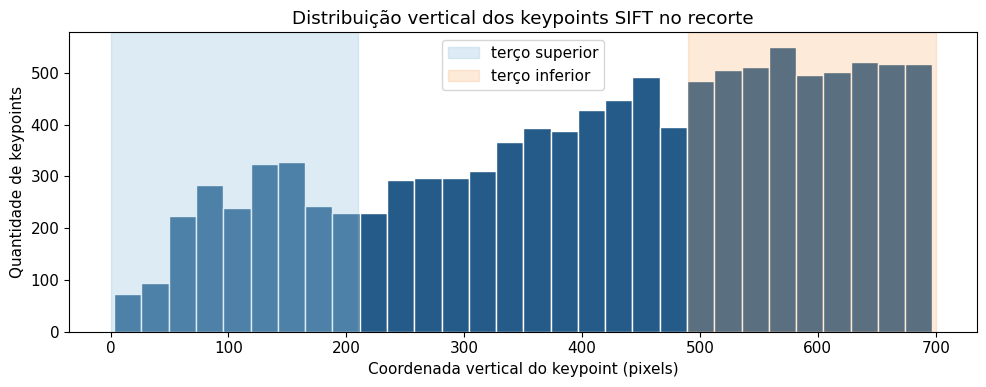

In [5]:
coordenadas_y = np.array([ponto.pt[1] for ponto in keypoints])
altura = imagem_cinza.shape[0]
terco_superior = coordenadas_y < 0.30 * altura
terco_inferior = coordenadas_y >= 0.70 * altura

print(f"Keypoints no terço superior: {terco_superior.sum():,}")
print(f"Keypoints no terço inferior: {terco_inferior.sum():,}")
print(f"Razão inferior/superior: {terco_inferior.sum() / terco_superior.sum():.2f}×")

plt.figure(figsize=(10, 4))
plt.hist(coordenadas_y, bins=30, color="#245b88", edgecolor="white")
plt.axvspan(0, 0.30 * altura, color="#9ecae1", alpha=0.35, label="terço superior")
plt.axvspan(0.70 * altura, altura, color="#fdae6b", alpha=0.25, label="terço inferior")
plt.xlabel("Coordenada vertical do keypoint (pixels)")
plt.ylabel("Quantidade de keypoints")
plt.title("Distribuição vertical dos keypoints SIFT no recorte")
plt.legend()
plt.tight_layout()

## Resumo

- O espaço de escalas permite procurar estruturas locais em tamanhos distintos.
- SIFT representa cada ponto por posição, escala, orientação e um descritor de 128 dimensões.
- Regiões com textura tendem a oferecer mais candidatos a correspondência do que áreas homogêneas.
- Em reconstrução 3D, a etapa seguinte é o casamento de descritores seguido de verificação geométrica.